In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset, het_breuschpagan, het_white
from statsmodels.stats.sandwich_covariance import cov_hac, se_cov
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt

In [ ]:
# Rolling change for funds

def rolling_monthly_returns(price_df, days_in_month=21):
    """
    Calculate rolling 1-month percent returns for each column (ticker) in a DataFrame.

    Args:
        price_df (pd.DataFrame): Daily adjusted prices with tickers as columns.
        days_in_month (int): Trading days in a month.

    Returns:
        pd.DataFrame: Rolling monthly percent returns for each ticker.
    """
    return price_df.pct_change(periods=days_in_month).dropna()

# Rolling change for risk free rate

def rolling_risk_free_return(rf_daily_series, days_in_month=21):
    """
    Calculate rolling compounded monthly returns from daily risk-free rates.

    Args:
        rf_daily_series (pd.Series): Daily risk-free rates (in decimal form).
        days_in_month (int): Number of trading days to use for one month.

    Returns:
        pd.Series: Rolling 1-month compounded risk-free returns.
    """
    return (1 + rf_daily_series).rolling(window=days_in_month).apply(lambda x: x.prod() - 1, raw=True).dropna()

#show significance levels

def significance_labels(df, pval_col='p_value', name='significance'):
    """
    Adds a column indicating significance level based on p-values.

    Args:
        df (pd.DataFrame): DataFrame with p-values.
        pval_col (str): Column name with p-values.

    Returns:
        pd.DataFrame: Original DataFrame with an added 'significance' column.
    """
    def label(p):
        if p < 0.01:
            return '*** (1%)'
        elif p < 0.05:
            return '** (5%)'
        elif p < 0.10:
            return '* (10%)'
        else:
            return 'ns'  # not significant

    df[name] = df[pval_col].apply(label)
    return df

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
names = pd.read_csv('/content/drive/MyDrive/Capstone_Project/names.csv')
rand_name = ['BRTNX', 'PRILX', 'QRVLX', 'QSMRX', 'TQMIX', 'FAFSX', 'TMDPX', 'AATSX', 'EMCAX', 'VEVYX', 'JNGTX', 'AATIX', 'JATSX', 'HICGX', 'VMGIX', 'PFSQX', 'WSMRX', 'PAWAX', 'PFSZX', 'PSGQX', 'CSJRX', 'FFSIX', 'EAFGX', 'AGRDX', 'ALGRX', 'CSJIX', 'ALZFX', 'MLNCX', 'IFPUX', 'MMMMX', 'SSHFX', 'MLNSX', 'ALGYX', 'LKSCX', 'LCCAX', 'BIPSX', 'GETGX', 'COFRX', 'PARWX', 'PSSRX', 'ATHYX', 'SPFAX', 'MLNAX', 'HCAIX', 'TMVIX', 'SMGIX', 'MLNIX', 'PNAIX', 'ALLIX']

In [ ]:
# Select tickers
funds = rand_name
market_index = '^GSPC' # S&P 500 Index
risk_free = '^IRX'     # 13-week T-bill as proxy for risk-free rate

---

### Monthly Analysis

In [ ]:
# Download monthly data
data_funds = yf.download(funds, start='2014-01-01', end='2024-12-31', interval='1mo')['Close']
data_market = yf.download([market_index, risk_free], start='2014-01-01', end='2024-12-31', interval='1mo')['Close']
data_funds = data_funds.dropna()
data_market = data_market.dropna()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  49 of 49 completed
[*********************100%***********************]  2 of 2 completed


In [ ]:
returns_funds = data_funds.pct_change().dropna()

returns_m = data_market.pct_change().dropna()
returns_m['^IRX'] = returns_m['^IRX'] / 100 / 12

In [ ]:
# create excess return table and variables
risk_free = returns_m['^IRX']
market = returns_m['^GSPC']

# reindex market and risk free rates
risk_free = risk_free.reindex(returns_funds.index).fillna(method='ffill')
market = market.reindex(returns_funds.index).fillna(method='ffill')

# excess returns
excess_m = market - risk_free
excess_f = pd.DataFrame()

# create excess returns table
for f in returns_funds:
    excess_f[f] = returns_funds[f] - risk_free

<ipython-input-8-e088c7d5bf05>:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  risk_free = risk_free.reindex(returns_funds.index).fillna(method='ffill')
<ipython-input-8-e088c7d5bf05>:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  market = market.reindex(returns_funds.index).fillna(method='ffill')


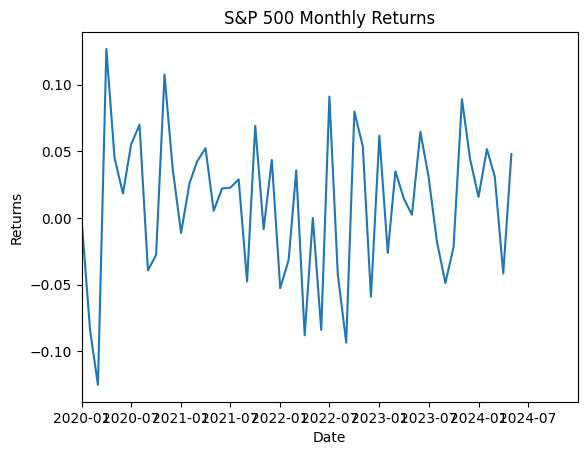

In [ ]:
plt.plot(returns_m['^GSPC'])
plt.xlabel('Date')
plt.xlim([pd.to_datetime('2020-01-01'), pd.to_datetime('2024-12-31')])
plt.ylabel('Returns')
plt.title('S&P 500 Monthly Returns')
plt.show()

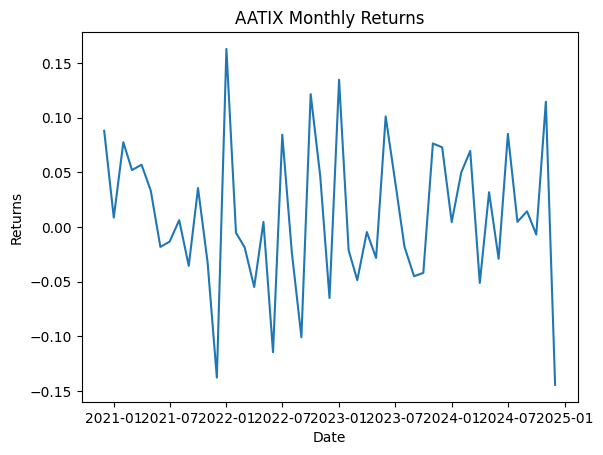

In [ ]:
plt.plot(returns_funds['AATIX'])
plt.xlabel('Date')
plt.ylabel('Returns')
plt.title('AATIX Monthly Returns')
plt.show()

In [ ]:
# run SIM to get alpha and beta for each fund
alpha_beta_sim = pd.DataFrame(columns=['alpha', 'beta'])

for n in returns_funds:
    sim_constant = sm.add_constant(market)
    sim_model = sm.OLS(returns_funds[n], sim_constant).fit()
    alpha, beta = sim_model.params
    alpha_beta_sim.loc[n] = [alpha, beta]

In [ ]:
# run SIM with excess returns to get parameters

params_sim_x = pd.DataFrame(columns=['r_squared', 'alpha', 'beta', 'se_alpha', 'se_beta'])

for n in returns_funds:
    sim_constant = sm.add_constant(excess_m)
    sim_model = sm.OLS(excess_f[n], sim_constant).fit()
    r_squared = sim_model.rsquared
    alpha, beta = sim_model.params
    se_alpha, se_beta = sim_model.bse
    params_sim_x.loc[n] = [r_squared, alpha, beta, se_alpha, se_beta]

#params_sim_x

In [ ]:
tests = pd.DataFrame(columns=['white', 'white_sig(0.05)', 'dw', 'dw_accept(0.3)', 'dw_accept(0.5)', 'reset_p_val', 'reset_sig(0.05)'])

for n in returns_funds:
    sim_constant = sm.add_constant(excess_m)
    sim_model = sm.OLS(excess_f[n], sim_constant).fit()

    # White Test for heteroskedasticity
    white_test = het_white(sim_model.resid, sim_model.model.exog)
    white = white_test[1]

    if white < 0.05:
      white_sig = True
    else:
      white_sig = False

    # Durbin Watson for autocorrelation
    dw_statistic = sm.stats.durbin_watson(sim_model.resid)
    abs_dw = abs(dw_statistic - 2)
    if abs_dw < 0.3:
      dw_thumb_3 = True
    else:
      dw_thumb_3 = False
    if abs_dw < 0.5:
      dw_thumb_5 = True
    else:
      dw_thumb_5 = False

    #ReSET test for linearity
    reset = linear_reset(sim_model)
    reset_p = reset.pvalue
    if reset_p < 0.05:
      reset_sig = True
    else:
      reset_sig = False

    tests.loc[n] = [white, white_sig, dw_statistic, dw_thumb_3, dw_thumb_5, reset_p, reset_sig]

,white,white_sig(0.05),dw,dw_accept(0.3),dw_accept(0.5),reset_p_val,reset_sig(0.05)
AATIX,0.969362,False,2.353372,False,True,0.296922,False
AATSX,0.967619,False,2.345233,False,True,0.291311,False
AGRDX,0.326049,False,2.253388,True,True,0.210420,False
ALGRX,0.762866,False,2.352884,False,True,0.142118,False
ALGYX,0.742667,False,2.340921,False,True,0.142607,False
ALLIX,0.461105,False,1.820122,True,True,0.606406,False
ALZFX,0.745552,False,2.342518,False,True,0.144763,False
ATHYX,0.483726,False,2.024099,True,True,0.149425,False
BIPSX,0.794172,False,1.725746,True,True,0.792973,False
BRTNX,0.385533,False,1.834162,True,True,0.613130,False


In [ ]:
n_obs = len(data_funds)
df = n_obs - 2          # degrees of freedom (for simple linear regression)

# Calculate t-statistic for H0: beta = 1
params_sim_x['t_stat_beta'] = (params_sim_x['beta'] - 1) / params_sim_x['se_beta']

# Calculate two-tailed p-values
params_sim_x['p_value_beta'] = 2 * stats.t.sf(abs(params_sim_x['t_stat_beta']), df=df)

In [ ]:
n_obs = len(data_funds)
df = n_obs - 2          # degrees of freedom (for simple linear regression)

# Calculate t-statistic for H0: beta = 1
params_sim_x['t_stat_alpha'] = (params_sim_x['alpha']) / params_sim_x['se_alpha']

# Calculate two-tailed p-values
params_sim_x['p_value_alpha'] = stats.t.sf(params_sim_x['t_stat_alpha'], df=df)

In [ ]:
params_sim_x

,r_squared,alpha,beta,se_alpha,se_beta,t_stat_beta,p_value_beta,t_stat_alpha,p_value_alpha
AATIX,0.261622,-0.001026,0.740049,0.008885,0.181348,-1.433436,0.158215,-0.115475,0.545725
AATSX,0.265287,-0.000862,0.740368,0.008806,0.179721,-1.444636,0.155057,-0.097900,0.538790
AGRDX,0.592530,-0.003284,0.923055,0.005471,0.111653,-0.689142,0.494052,-0.600261,0.724422
ALGRX,0.553539,-0.001853,0.953886,0.006123,0.124958,-0.369036,0.713724,-0.302601,0.618249
ALGYX,0.561091,-0.001657,0.958387,0.006058,0.123641,-0.336562,0.737914,-0.273495,0.607177
ALLIX,0.672366,-0.004575,0.929381,0.004637,0.094632,-0.746252,0.459155,-0.986680,0.835626
ALZFX,0.560106,-0.001680,0.957790,0.006066,0.123811,-0.340922,0.734650,-0.276897,0.608476
ATHYX,0.402626,-0.008850,0.885768,0.007711,0.157378,-0.725849,0.471456,-1.147778,0.871626
BIPSX,0.102938,-0.011718,0.791827,0.016706,0.340961,-0.610547,0.544380,-0.701422,0.756787
BRTNX,0.737806,-0.000699,0.883757,0.003765,0.076846,-1.512664,0.136922,-0.185586,0.573224


In [ ]:
params_sim_x['r_squared'].describe()

,r_squared
count,49.000000
mean,0.426168
std,0.163251
min,0.102938
25%,0.334543
50%,0.414515
75%,0.560106
max,0.750694


---

### Rolling Analysis

In [ ]:
# Download Daily Data
data_funds_daily = yf.download(funds, start='2014-01-01', end='2024-12-31', interval='1d')['Close']
data_market_daily = yf.download([market_index, risk_free], start='2014-01-01', end='2024-12-31', interval='1d')['Close']
data_funds_daily = data_funds_daily.dropna()
data_market_daily = data_market_daily.dropna()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  49 of 49 completed
[*********************100%***********************]  2 of 2 completed


In [ ]:
fund_rolling = rolling_monthly_returns(data_funds_daily)

In [ ]:
market_rolling = pd.DataFrame(columns=['^GSPC', '^IRX'])
market_rolling['^GSPC'] = rolling_monthly_returns(data_market_daily['^GSPC'])

# First convert annualized % to daily decimal
market_rolling['^IRX'] = data_market_daily['^IRX'] / 100 / 252
market_rolling['^IRX'] = rolling_risk_free_return(market_rolling['^IRX'])

market_rolling = market_rolling.dropna()

In [ ]:
print(len(fund_rolling))
len(market_rolling)

1025


2725

In [ ]:
# create excess return table and variables
rfr = market_rolling['^IRX']
market_r = market_rolling['^GSPC']

# reindex market and risk free rates
rfr = rfr.reindex(fund_rolling.index).fillna(method='ffill')
market_r = market_r.reindex(fund_rolling.index).fillna(method='ffill')

# excess returns
excess_m_r = market_r - rfr
excess_f_r = pd.DataFrame()

# create excess returns table
for f in fund_rolling:
    excess_f_r[f] = fund_rolling[f] - rfr

<ipython-input-59-9d897455b704>:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  rfr = rfr.reindex(fund_rolling.index).fillna(method='ffill')
<ipython-input-59-9d897455b704>:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  market_r = market_r.reindex(fund_rolling.index).fillna(method='ffill')


In [ ]:
# run SIM with excess returns to get parameters

params_sim_x_r = pd.DataFrame(columns=['alpha', 'beta', 'se_alpha', 'se_beta'])

for n in fund_rolling:
    sim_constant = sm.add_constant(excess_m_r)
    sim_model = sm.OLS(excess_f_r[n], sim_constant).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    alpha, beta = sim_model.params
    se_alpha, se_beta = sim_model.bse
    params_sim_x_r.loc[n] = [alpha, beta, se_alpha, se_beta]

In [ ]:
tests = pd.DataFrame(columns=['white', 'dw', 'dw_accept(0.3)', 'dw_accept(0.5)'])

for n in fund_rolling:
    sim_constant = sm.add_constant(excess_m_r)
    sim_model = sm.OLS(excess_f_r[n], sim_constant).fit(cov_type='HAC', cov_kwds={'maxlags': 3})

    # White Test for heteroskedasticity
    white_test = het_white(sim_model.resid, sim_model.model.exog)
    white = white_test[1]

    # Durbin Watson for autocorrelation
    dw_statistic = sm.stats.durbin_watson(sim_model.resid)
    abs_dw = abs(dw_statistic - 2)
    if abs_dw < 0.3:
      dw_thumb_3 = True
    else:
      dw_thumb_3 = False
    if abs_dw < 0.5:
      dw_thumb_5 = True
    else:
      dw_thumb_5 = False

    tests.loc[n] = [white, dw_statistic, dw_thumb_3, dw_thumb_5]

tests

,white,dw,dw_accept(0.3),dw_accept(0.5)
AATIX,2.851724e-04,0.085905,False,False
AATSX,2.846341e-04,0.085776,False,False
AGRDX,1.107520e-02,0.082184,False,False
ALGRX,4.373285e-01,0.170589,False,False
ALGYX,4.193219e-01,0.166277,False,False
ALLIX,2.573636e-03,0.098641,False,False
ALZFX,4.197328e-01,0.166992,False,False
ATHYX,2.692142e-01,0.097635,False,False
BIPSX,2.197400e-02,0.117716,False,False
BRTNX,4.072711e-03,0.141378,False,False


In [ ]:
n_obs = len(fund_rolling)
df = n_obs - 2          # degrees of freedom (for simple linear regression)

# Calculate t-statistic for H0: beta = 1
params_sim_x_r['t_stat_beta'] = (params_sim_x_r['beta'] - 1) / params_sim_x_r['se_beta']

# Calculate two-tailed p-values
params_sim_x_r['p_value_beta'] = 2 * stats.t.sf(abs(params_sim_x_r['t_stat_beta']), df=df)

# add significance levels
params_sim_x_r = significance_labels(params_sim_x_r, pval_col='p_value_beta', name='sig_b')

In [ ]:
n_obs = len(fund_rolling)
df = n_obs - 2          # degrees of freedom (for simple linear regression)

# Calculate t-statistic for H0: beta = 1
params_sim_x_r['t_stat_alpha'] = (params_sim_x_r['alpha']) / params_sim_x_r['se_alpha']

# Calculate two-tailed p-values
params_sim_x_r['p_value_alpha'] = stats.t.sf(params_sim_x_r['t_stat_alpha'], df=df)

# add significance levels
params_sim_x_r = significance_labels(params_sim_x_r, pval_col='p_value_alpha', name='sig_a')

In [ ]:
params_sim_x_r

,alpha,beta,se_alpha,se_beta,t_stat_beta,p_value_beta,sig_b,t_stat_alpha,p_value_alpha,sig_a
AATIX,0.001177,0.970996,0.001062,0.024807,-1.169197,2.425967e-01,ns,1.108829,1.338823e-01,ns
AATSX,0.001363,0.971148,0.001061,0.024806,-1.163110,2.450560e-01,ns,1.284149,9.969025e-02,* (10%)
AGRDX,-0.000612,1.223429,0.000692,0.016182,13.807153,6.862248e-40,*** (1%),-0.883134,8.113143e-01,ns
ALGRX,-0.000232,1.276007,0.000858,0.020047,13.767953,1.085022e-39,*** (1%),-0.270587,6.066184e-01,ns
ALGYX,0.000042,1.276200,0.000858,0.020047,13.777496,9.705823e-40,*** (1%),0.049027,4.804535e-01,ns
ALLIX,-0.000966,1.147256,0.000591,0.013815,10.659387,3.139831e-25,*** (1%),-1.633913,9.487076e-01,ns
ALZFX,0.000008,1.276385,0.000858,0.020045,13.788132,8.571570e-40,*** (1%),0.009676,4.961408e-01,ns
ATHYX,-0.005400,1.302265,0.000988,0.023098,13.086068,2.717710e-36,*** (1%),-5.463025,1.000000e+00,ns
BIPSX,-0.006122,1.340157,0.002379,0.055586,6.119450,1.335600e-09,*** (1%),-2.573600,9.948977e-01,ns
BRTNX,0.003378,0.861416,0.000500,0.011690,-11.855137,1.804166e-30,*** (1%),6.752275,1.217930e-11,*** (1%)
